# Analyse des KPI – E-commerce Dataset
---
## Objectif
Ce notebook a pour but de synthétiser les indicateurs clés de performance (KPI) issus du dataset *Online Retail*.
Ces KPI serviront de base au développement du Dashboard interactif Streamlit.

## Indicateurs calculés
- **Chiffre d'affaires total (CA)** : somme des ventes (`Quantity × UnitPrice`).
- **Nombre de transactions** : nombre unique de factures (`InvoiceNo`).
- **Panier moyen** : rapport entre le CA total et le nombre de transactions.
- **Nombre de clients uniques** : nombre distinct de `CustomerID`.
- **Top 5 produits** : classement par volume de ventes et par chiffre d'affaires.
- **Top 5 pays** : classement par nombre de transactions.
- **Évolution temporelle** : suivi du CA par mois.

## Importance des KPI
- Ils permettent de **résumer** les résultats de l'EDA en chiffres clés.
- Ils offrent une **vue synthétique** pour les décideurs et managers.
- Ils facilitent la **comparaison temporelle et géographique**.
- Ils constituent la **base du Dashboard interactif**.

## Prochaines étapes
- Intégrer ces KPI dans un Dashboard Streamlit (`04_streamlit_app.py`).
- Ajouter des filtres interactifs (pays, période, produit).
- Déployer l'application pour permettre une exploration dynamique des données.
---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# charger les données nettoyées (notebook 01)
df = pd.read_csv('../data/processed/OnlineRetail_clean.csv')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [2]:
df.shape

(392692, 9)

In [3]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')

In [5]:
# calculs des KPI
ca_total = df['TotalPrice'].sum()
nb_transactions = df['InvoiceNo'].nunique()
panier_moyen = ca_total / nb_transactions
nb_clients = df['CustomerID'].nunique()

top_produits_qte = df.groupby('Description')['Quantity'].sum().nlargest(5)
top_produits_ca = df.groupby('Description')['TotalPrice'].sum().nlargest(5)
top_pays = df.groupby('Country')['InvoiceNo'].nunique().nlargest(5)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
evolution_ca = df.groupby('YearMonth')['TotalPrice'].sum()

In [6]:
print("Chiffre d'affaires total:", round(ca_total, 2))
print("Nombre de transactions:", nb_transactions)
print("Panier moyen:", round(panier_moyen, 2))
print("Nombre de clients uniques:", nb_clients)
print("\nTop 5 des produits (quantité):\n", top_produits_qte)
print("\nTop 5 des produits (chiffres d'affaires):\n", top_produits_ca)
print("\nTop 5 des pays (transactions):\n", top_pays)

Chiffre d'affaires total: 8887208.89
Nombre de transactions: 18532
Panier moyen: 479.56
Nombre de clients uniques: 4338

Top 5 des produits (quantité):
 Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
Name: Quantity, dtype: int64

Top 5 des produits (chiffres d'affaires):
 Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
Name: TotalPrice, dtype: float64

Top 5 des pays (transactions):
 Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Name: InvoiceNo, dtype: int64


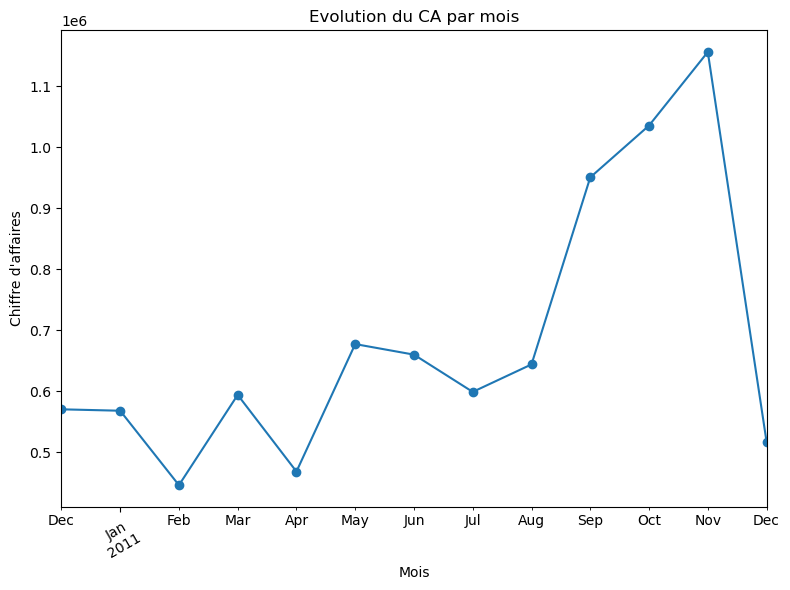

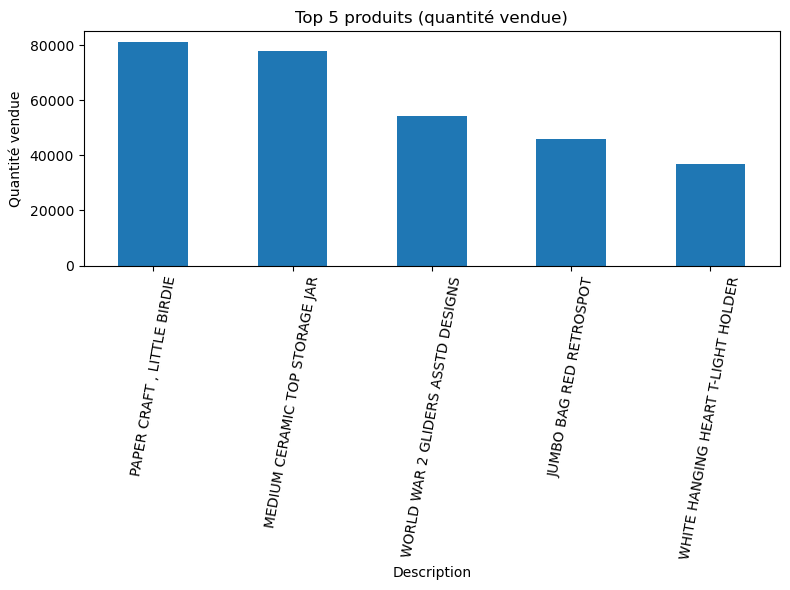

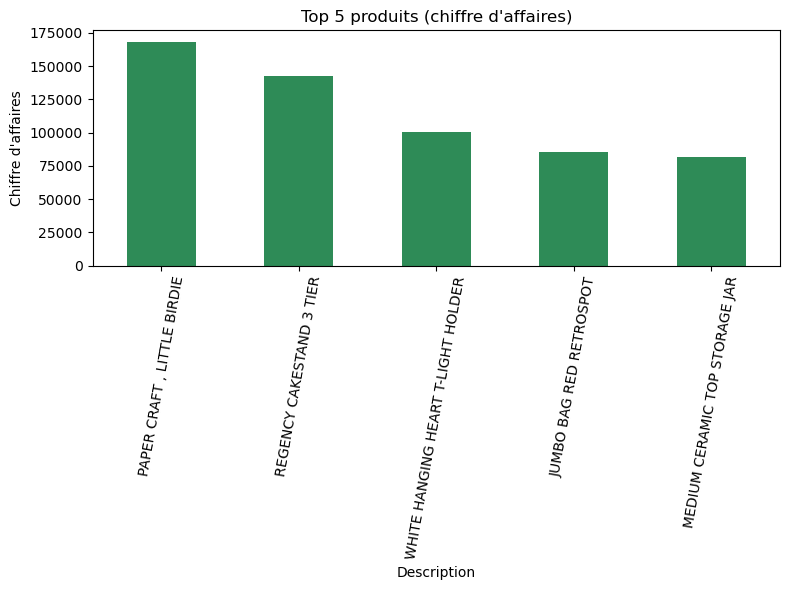

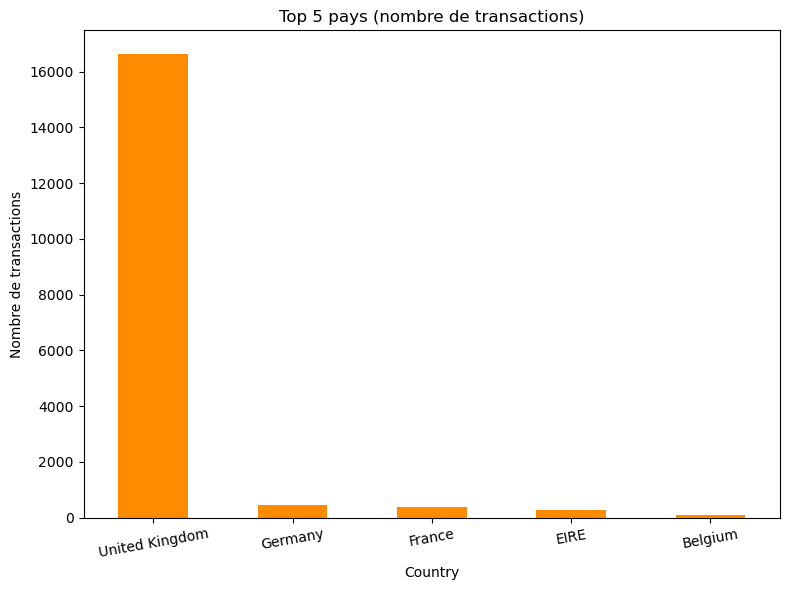

In [22]:
plt.figure(figsize=(8,6))
evolution_ca.plot(kind="line", marker="o", title="Evolution du CA par mois")
plt.ylabel("Chiffre d'affaires")
plt.xlabel("Mois")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
top_produits_qte.plot(kind="bar", title="Top 5 produits (quantité vendue)")
plt.ylabel("Quantité vendue")
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
top_produits_ca.plot(kind="bar", title="Top 5 produits (chiffre d'affaires)", color="seagreen")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
top_pays.plot(kind="bar", title="Top 5 pays (nombre de transactions)", color="darkorange")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

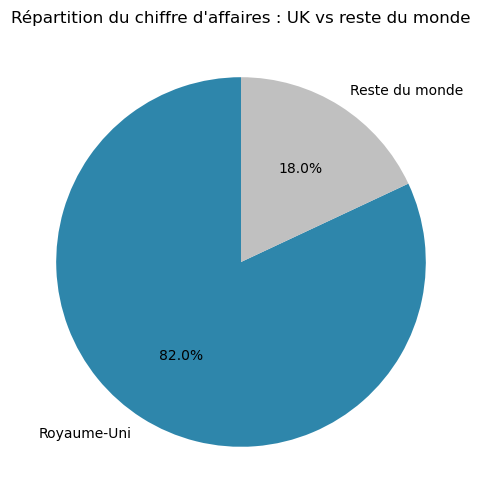

In [23]:
# Répartition du CA : UK vs reste du monde
ca_par_pays = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
ca_uk = ca_par_pays.get('United Kingdom', 0)
ca_reste = ca_par_pays.sum() - ca_uk

plt.figure(figsize=(6,6))
plt.pie([ca_uk, ca_reste], labels=['Royaume-Uni', 'Reste du monde'],
        autopct='%1.1f%%', colors=['#2E86AB', '#C0C0C0'], startangle=90)
plt.title("Répartition du chiffre d'affaires : UK vs reste du monde")
plt.show()

Fréquence d'achat moyenne : 4.27 commandes/client
Clients avec une seule commande : 1493 (34.4% des clients)
Clients récurrents (2+ commandes) : 2845 (65.6% des clients)


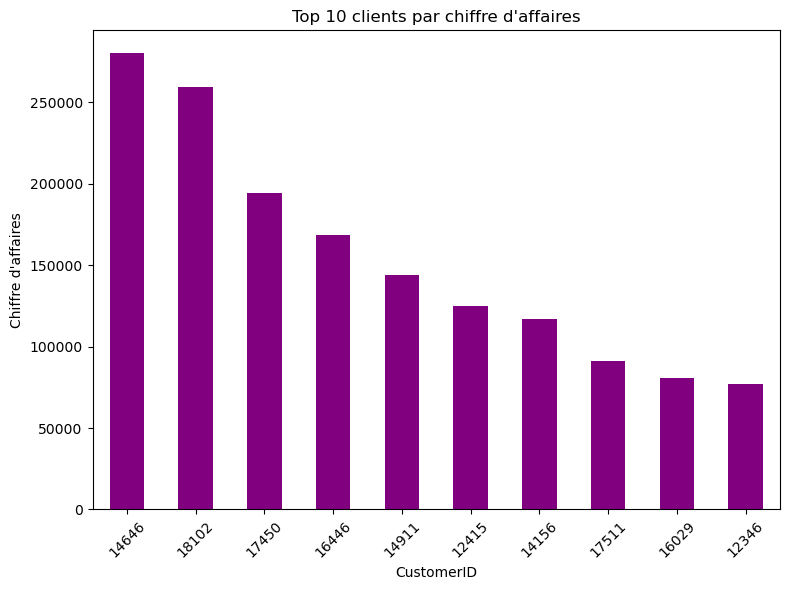

In [24]:
# Fréquence d'achat par client (nb de commandes distinctes)
commandes_par_client = df.groupby('CustomerID')['InvoiceNo'].nunique()

print("Fréquence d'achat moyenne :", round(commandes_par_client.mean(), 2), "commandes/client")
print("Clients avec une seule commande :", (commandes_par_client == 1).sum(),
      f"({(commandes_par_client == 1).mean()*100:.1f}% des clients)")
print("Clients récurrents (2+ commandes) :", (commandes_par_client > 1).sum(),
      f"({(commandes_par_client > 1).mean()*100:.1f}% des clients)")

# Top 10 clients par chiffre d'affaires
top_clients = df.groupby('CustomerID')['TotalPrice'].sum().nlargest(10)
plt.figure(figsize=(8,6))
top_clients.plot(kind='bar', color='purple')
plt.title("Top 10 clients par chiffre d'affaires")
plt.ylabel("Chiffre d'affaires")
plt.xlabel("CustomerID")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

Les KPI calculés dans ce notebook (CA total, transactions, panier moyen, clients uniques,
top produits/pays, évolution mensuelle, répartition géographique, fidélité client) sont
sauvegardés dans `data/processed/kpi_summary.csv`, prêts pour le dashboard Streamlit.

**Point clé** : 65,6% des clients sont récurrents (2+ commandes), signe d'une base de
clientèle fidèle plutôt que d'achats ponctuels — un indicateur de santé commerciale positif.
Le Royaume-Uni concentre 82% du chiffre d'affaires, une dépendance géographique à surveiller.

In [25]:
kpi_data = {
    "CA_total": [ca_total],
    "Transactions": [nb_transactions],
    "Panier_moyen": [panier_moyen],
    "Clients_uniques": [nb_clients]
}

kpi_df = pd.DataFrame(kpi_data)
kpi_df.to_csv("../data/processed/kpi_summary.csv", index=False)

print("Fichier kpi_summary.csv sauvegardé avec succès.")

Fichier kpi_summary.csv sauvegardé avec succès.


## Conclusion

Les KPI calculés dans ce notebook (CA total, transactions, panier moyen, clients uniques,
top produits/pays, évolution mensuelle) sont maintenant sauvegardés dans
`data/processed/kpi_summary.csv` et prêts à alimenter le dashboard Streamlit.